# `Capstone Project`

# Customer Segmentation using Unsupervised Machine Learning

## Assignment Overview
In this assignment, you will apply **Descriptive Data Mining** to perform **customer segmentation** on mall customer data. You will explore   clustering techniques:
- **K-Means Clustering**




## Objectives
By completing this assignment, you will:
1. Perform **Exploratory Data Analysis (EDA)** to understand the dataset.
2. **Preprocess and wrangle** the data to prepare it for clustering.
3. Implement **K-Means on the dataset.**


---

## Dataset Description
You will use a dataset containing information about mall customers, including attributes such as:
- **Customer ID** (Unique identifier)
- **Gender** (Male/Female)
- **Age** (Customer's age)
- **Annual Income** (in thousands of dollars)
- **Spending Score** (Assigned based on cusm an ierarchical cstering.
- Fine-tune hyperparameters in DBSCAN to achieve better clustering.

Good luck! 🚀


# import packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as snn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import preprocessing

import warnings
warnings.filterwarnings('ignore')

#%matplotlib inline

In [ ]:
# load data
df=pd.read_csv("/content/Mall_Customers.csv")

In [ ]:
df.shape  # (number of rows , number of columns)

(200, 5)

In [ ]:
df.head()  # show first 5 rows

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.shape

(200, 5)

In [ ]:
df=df.drop_duplicates()

In [ ]:
df.shape

(200, 5)

In [ ]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
df.drop("CustomerID",axis=1,inplace=True)

In [ ]:
df.columns

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

In [ ]:
df.dtypes

,0
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


In [ ]:
# label encoding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["Gender"]=le.fit_transform(df["Gender"])

In [ ]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [ ]:
df["Gender"].value_counts()  # 1 male  , 0 female

,count
Gender,
0,112
1,88


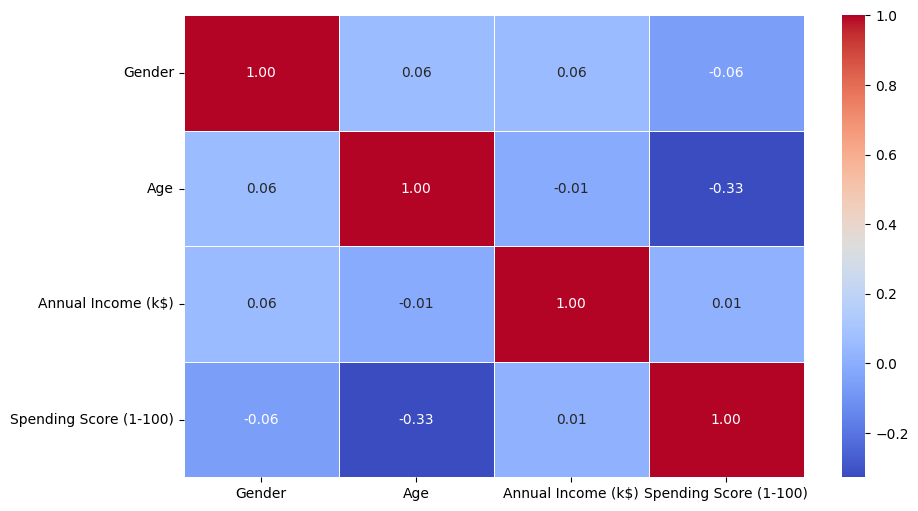

In [ ]:
import seaborn as sns
plt.figure(figsize=(10,6))
corr=df.corr()
sns.heatmap(corr,annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.show()  # gender no category   # chi square test  # heatmap befor scaling -1---+1

# univariate analysis

In [ ]:
numerical_features=[column for column in df.columns if df[column].dtypes != "0"]

In [ ]:
numerical_features

['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

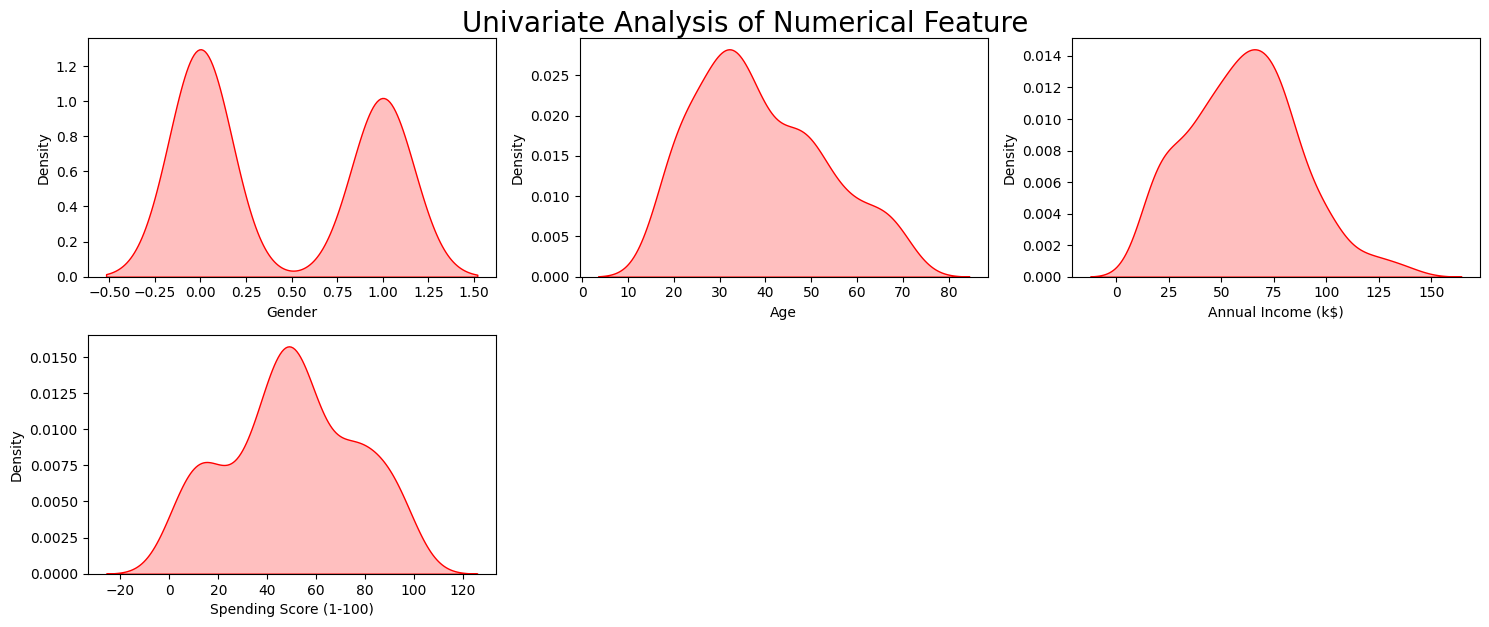

In [ ]:
plt.figure(figsize=(15,15))
plt.suptitle("Univariate Analysis of Numerical Feature",fontsize=20,fontweight=20)
for i in range(0,len(numerical_features)):
    plt.subplot(5,3,i+1)
    sns.kdeplot(x=df[numerical_features[i]],shade=True,color="r")
    plt.xlabel(numerical_features[i])
    plt.tight_layout()

<Axes: xlabel='Gender', ylabel='count'>

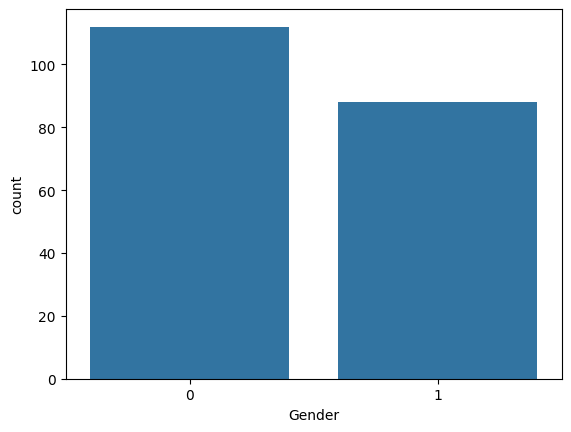

In [ ]:
sns.countplot(df,x=df['Gender'])

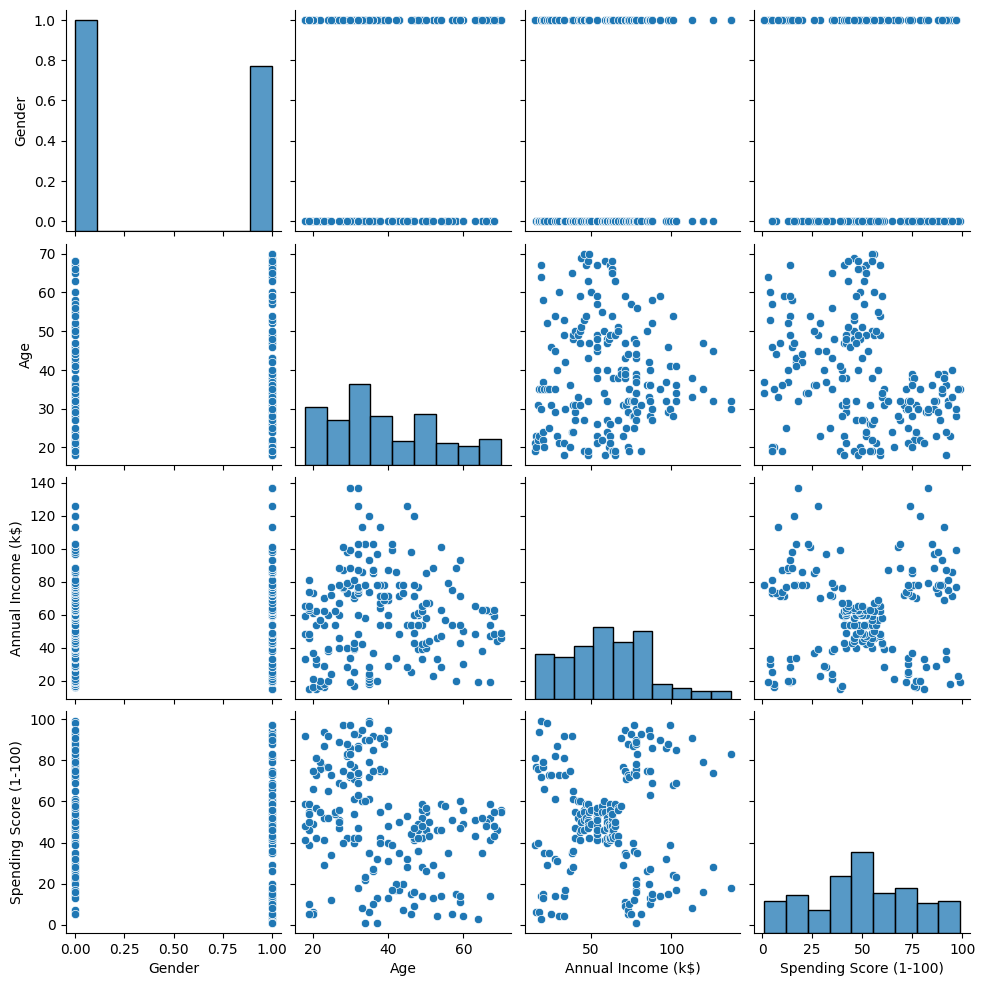

In [ ]:
sns.pairplot(df)
plt.show()

# model

In [ ]:
x=df[["Annual Income (k$)","Spending Score (1-100)"]].values

kmean

In [ ]:
from sklearn.cluster import KMeans
Wcss=[]

for i in range(1,11):
  Kmeans_model=KMeans(n_clusters=i,init='k-means++',random_state=0)
  Kmeans_model.fit(x)
  Wcss.append(Kmeans_model.inertia_)

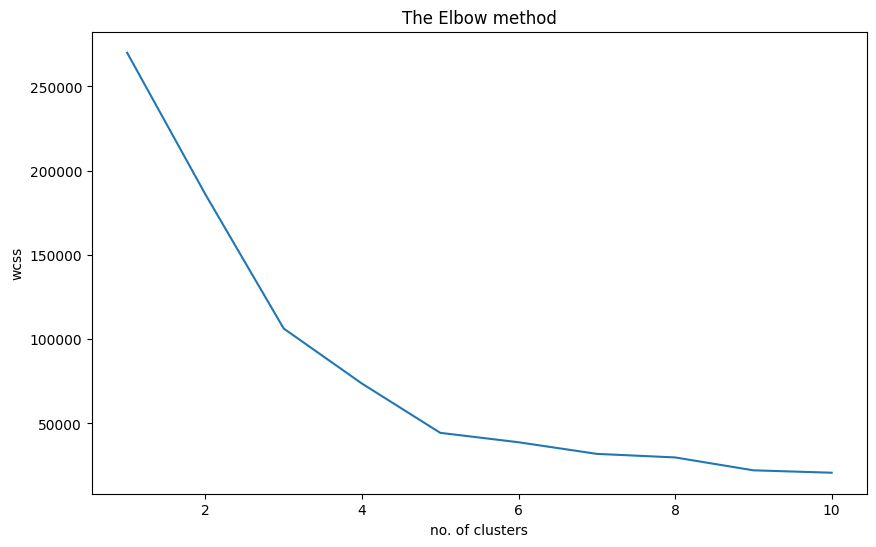

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(range(1,11),Wcss)
plt.title("The Elbow method")
plt.xlabel('no. of clusters')
plt.ylabel('wcss')
plt.show()

In [ ]:
Kmean_model = KMeans(n_clusters=5, random_state=0)

y_means = Kmean_model.fit_predict(x)

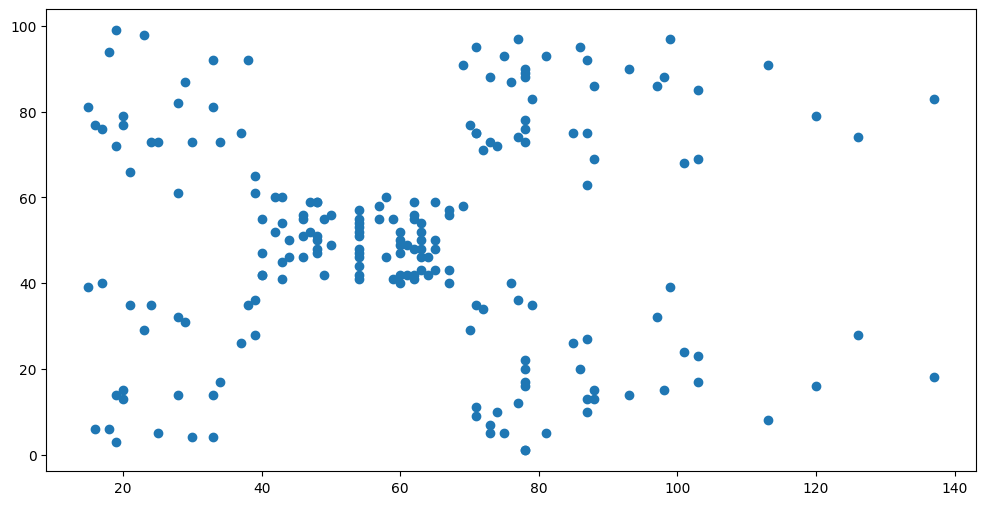

In [ ]:
plt.figure(figsize=(12,6))

x_plot = x[:,0]
y_plot = x[:,1]
plt.scatter(x_plot,y_plot)

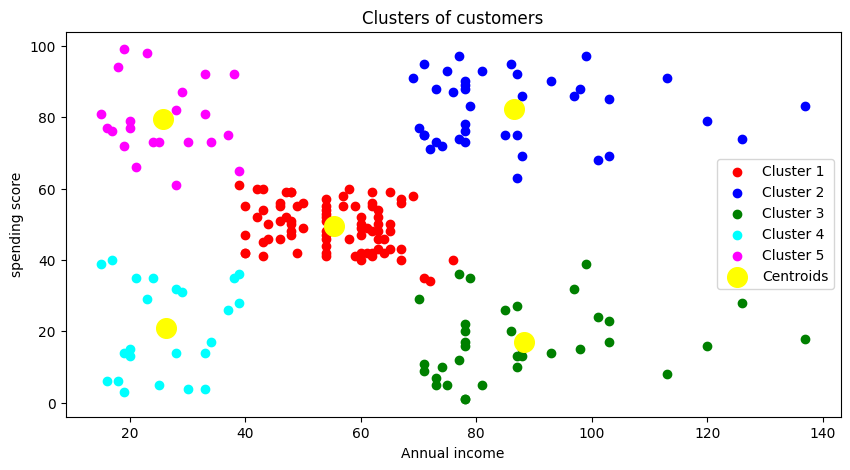

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(x[y_means == 0,0],x[y_means == 0,1], c = 'red', label = 'Cluster 1' )
plt.scatter(x[y_means == 1,0],x[y_means == 1,1], c = 'blue', label = 'Cluster 2' )
plt.scatter(x[y_means == 2,0],x[y_means == 2,1], c = 'green', label = 'Cluster 3' )
plt.scatter(x[y_means == 3,0],x[y_means == 3,1], c = 'cyan', label = 'Cluster 4' )
plt.scatter(x[y_means == 4,0],x[y_means == 4,1], c = 'magenta', label = 'Cluster 5' )
plt.scatter(Kmean_model.cluster_centers_[:,0],Kmean_model.cluster_centers_[:,1], s = 200, c = 'yellow', label = 'Centroids')


plt.title("Clusters of customers")
plt.xlabel('Annual income')
plt.ylabel('spending score')

plt.legend()
plt.show()# plt.scatter()

In [ ]:
import plotly.graph_objs as go
import plotly as py

labels3 = Kmean_model.labels_

df['label3'] =  labels3
trace1 = go.Scatter3d(
    x= df['Age'],
    y= df['Spending Score (1-100)'],
    z=df['Annual Income (k$)'],
    mode='markers',
     marker=dict(
        color = df['label3'],
        size= 20,
        line=dict(
            color= df['label3'],
            width= 12
        ),
        opacity=0.8
     )
)
data = [trace1]
layout = go.Layout(
#     margin=dict(
#         l=0,
#         r=0,
#         b=0,
#         t=0
#     )
    title= 'Clusters',
    scene = dict(
            xaxis = dict(title  = 'Age'),
            yaxis = dict(title  = 'Spending Score'),
            zaxis = dict(title  = 'Annual Income')
        )
)
fig = go.Figure(data=data, layout=layout)
py.offline.iplot(fig)

**save model**

In [ ]:
import joblib
joblib.dump(Kmean_model, 'kmeans_model.pkl')

['kmeans_model.pkl']